<Figure size 500x300 with 0 Axes>

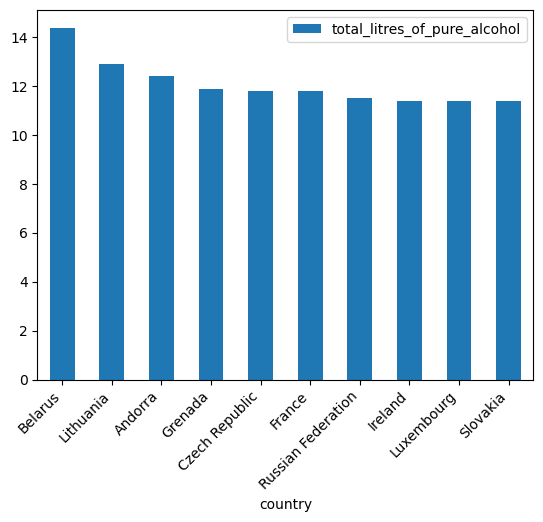

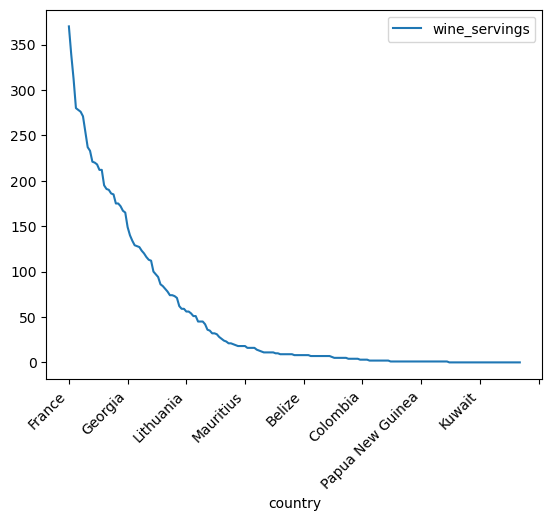

In [29]:

import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
#df

#1
#Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)
primi_10 = df.nlargest(10, 'total_litres_of_pure_alcohol')[['country', 'total_litres_of_pure_alcohol']]
#primi_10

#Calcola la media del consumo di birra, vino, e distillati
media_birra = df['beer_servings'].mean()
media_vino = df['wine_servings'].mean()
media_spirit = df['spirit_servings'].mean()
#print(f"Media consumo Birra: {media_birra:.2f}")
#print(f"Media consumo Vino: {media_vino:.2f}")
#print(f"Media consumo Spirit: {media_spirit:.2f}")

#Crea una nuova colonna alcohol_index
df['alcohol_index'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings']) / 3
#print(df.head())

#Trova il paese con il valore massimo di alcohol_index
paese_massimo = df.loc[df['alcohol_index'].idxmax()]
#print(paese_massimo)

#Filtra solo i paesi che consumano più di 100 birre all’anno
consumo_maggiore = df[df['beer_servings'] > 100][['country', 'beer_servings']].sort_values('beer_servings', ascending=False)
#print(consumo_maggiore)

#Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)
import matplotlib.pyplot as plt 
top_10 = df.nlargest(10, 'total_litres_of_pure_alcohol')
plt.figure(figsize=(5,3))
top_10.plot(x='country', y='total_litres_of_pure_alcohol', kind='bar')
plt.xticks(rotation=45, ha='right')
plt.show()
#Crea un line plot con wine_servings ordinato per paese (usa sort_values)
ordinati_vino = df.sort_values('wine_servings', ascending=False)
ordinati_vino.plot(x='country', y='wine_servings', kind='line')
plt.xticks(rotation=45, ha='right')
plt.show()


123286.27407182401
785740
15000.0
960000.0


<Axes: title={'center': 'Stipendio Medio Annuale per Titolo di Lavoro'}, ylabel='job_title_short'>

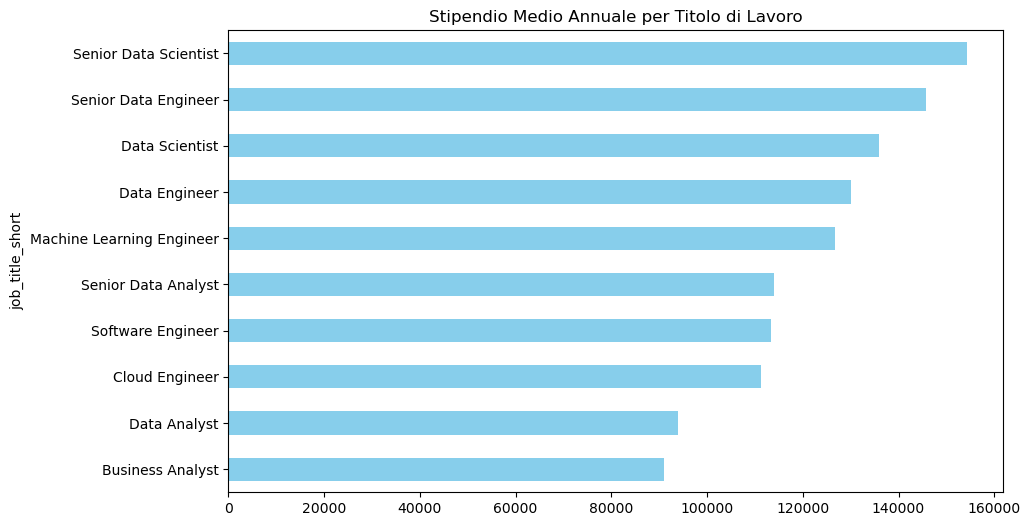

In [20]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df
#2
#Lo stipendio medio annuale (salary_year_avg)
stipendio_medio_annuale = df['salary_year_avg'].mean()
print(stipendio_medio_annuale)
#Il numero totale di offerte di lavoro (job count)
totale_job_count = df['job_title'].count()
print(totale_job_count)
#L’intervallo degli stipendi: valore minimo e massimo (min / max)
min_salary = df['salary_year_avg'].min()
max_salary = df['salary_year_avg'].max()
print(min_salary)
print(max_salary)
#Rappresenta graficamente lo stipendio medio (salary_year_avg) per job_title_short usando un grafico a barre orizzontali.
#Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.
plt.figure(figsize=(10,6))
stipendio_medio_job_title = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending=True)
plt.title('Stipendio Medio Annuale per Titolo di Lavoro')
plt.xlabel('Stipendio Medio ($)')
plt.ylabel('Titolo del Lavoro')
stipendio_medio_job_title.plot(kind='barh', color='skyblue')

Sun


<Axes: title={'center': 'Conto Medio per Giorno'}, xlabel='day', ylabel='Valore Medio ($)'>

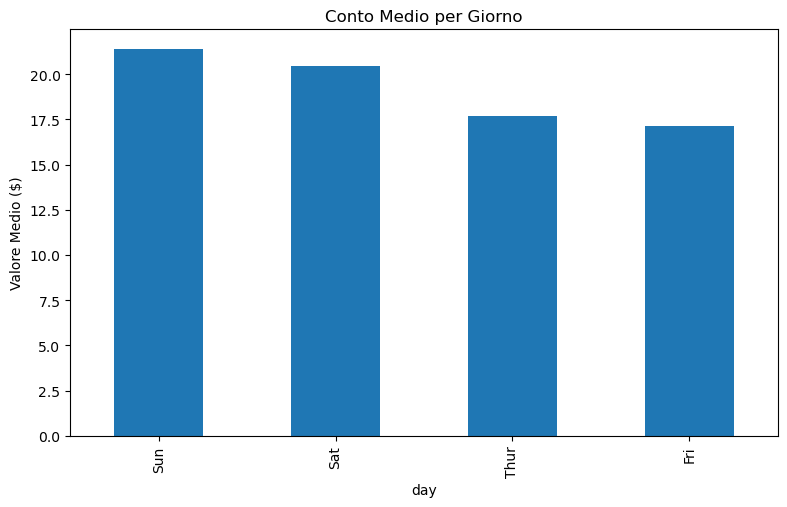

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

#3 Analizza i seguenti aspetti per ogni giorno (day):
#Il conto medio (total_bill)
#Il numero totale di osservazioni (conteggio delle righe)
#Il valore minimo e massimo del conto (total_bill → min / max)
conto_medio_giorno = df.groupby('day')['total_bill'].agg(['mean', 'count', 'min', 'max']).rename(columns={
    'mean': 'Conto Medio',
    'count': 'Osservazioni',
    'min': 'Minimo',
    'max': 'Massimo'
})
conto_medio_giorno
#Crea una nuova colonna conto_per_persona che sia: total_bill / size
df['conto_per_persona'] = round(df['total_bill'] / df['size'], 2)
df
#Trova il giorno con il conto medio più alto
max_conto_medio = conto_medio_giorno['Conto Medio'].idxmax()
print(max_conto_medio)
#Rappresenta graficamente il conto medio (total_bill) per giorno usando un grafico a barre.
#Ordina i dati dal valore più alto al più basso.
#Aggiungi titolo ed etichette agli assi.
plt.figure(figsize=(8,5))
plt.title('Conto Medio per Giorno')
plt.xlabel('Giorno della Settimana')
plt.ylabel('Valore Medio ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
dat = conto_medio_giorno['Conto Medio'].sort_values(ascending=False)
dat.plot(kind='bar')
